In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import TimeDistributed, Conv2D, MaxPooling2D, Flatten, LSTM, Dense, Dropout
from tensorflow.keras.utils import to_categorical , plot_model
from tensorflow.keras.optimizers import Adam

2026-04-02 20:25:13.238407: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775161513.500519      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775161513.572357      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775161514.156164      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775161514.156204      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775161514.156207      55 computation_placer.cc:177] computation placer alr

In [5]:
selected_classes = [
    "Basketball",
    "Diving",
    "HorseRace",
    "JumpRope",
    "VolleyballSpiking",
    "WalkingWithDog",
    "BenchPress",
    "Biking",
    "GolfSwing",
    "HighJump",
    "Kayaking",
    "PullUps",
    "PushUps",
    "RopeClimbing",
    "SkateBoarding",
    "SoccerJuggling",
    "Swing",
    "TrampolineJumping"
]


dataset_path = "/kaggle/input/datasets/pypiahmad/realistic-action-recognition-ucf50/UCF50"

for cls in selected_classes:
    print(f"{cls} → Total videos:", len(os.listdir(os.path.join(dataset_path, cls))))


Basketball → Total videos: 137
Diving → Total videos: 153
HorseRace → Total videos: 127
JumpRope → Total videos: 148
VolleyballSpiking → Total videos: 116
WalkingWithDog → Total videos: 123
BenchPress → Total videos: 160
Biking → Total videos: 145
GolfSwing → Total videos: 142
HighJump → Total videos: 123
Kayaking → Total videos: 157
PullUps → Total videos: 120
PushUps → Total videos: 106
RopeClimbing → Total videos: 130
SkateBoarding → Total videos: 120
SoccerJuggling → Total videos: 156
Swing → Total videos: 137
TrampolineJumping → Total videos: 119


In [ ]:
def extract_frames(video_path, num_frames=20):
    frames = []
    cap = cv2.VideoCapture(video_path)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    frame_interval = max(total_frames // num_frames, 1)
    
    count = 0
    while len(frames) < num_frames and cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break
        if count % frame_interval == 0:
            frame = cv2.resize(frame, (64, 64))
            frame = frame / 255.0  
            frames.append(frame)
        count += 1
    cap.release()

    while len(frames) < num_frames:
        frames.append(frames[-1])
    
    return np.array(frames)


In [11]:
X = []
y = []

for class_index, cls in enumerate(selected_classes):
    class_path = os.path.join(dataset_path, cls)
    videos = os.listdir(class_path)  

    for video in videos:
        video_path = os.path.join(class_path, video)
        frames = extract_frames(video_path, num_frames=20)
        if frames.shape == (20, 64, 64, 3): 
            X.append(frames)
            y.append(class_index)

X = np.array(X)
y = to_categorical(y)

print(" Data Loaded:")
print("X shape:", X.shape)  
print("y shape:", y.shape) 


 Data Loaded:
X shape: (2419, 20, 64, 64, 3)
y shape: (2419, 18)


In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training videos:", X_train.shape[0])
print("Testing videos:", X_test.shape[0])


Training videos: 1935
Testing videos: 484


In [13]:
model = Sequential()
model.add(TimeDistributed(Conv2D(32, (3,3), activation='relu'), input_shape=(20, 64, 64, 3)))
model.add(TimeDistributed(MaxPooling2D(2,2)))
model.add(TimeDistributed(Conv2D(64, (3,3), activation='relu')))
model.add(TimeDistributed(MaxPooling2D(2,2)))
model.add(TimeDistributed(Flatten()))

model.add(LSTM(64))
model.add(Dropout(0.5))
model.add(Dense(18, activation='softmax'))
model.compile(loss='categorical_crossentropy', optimizer=Adam(learning_rate=0.0005), metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/wrapper.py:27: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
2026-04-02 20:29:28.683681: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [16]:
history = model.fit(X_train, y_train, epochs=10, validation_data=(X_test, y_test), batch_size=4)


Epoch 1/10
484/484 ━━━━━━━━━━━━━━━━━━━━ 467s 951ms/step - accuracy: 0.1609 - loss: 2.7676 - val_accuracy: 0.4339 - val_loss: 1.9352
Epoch 2/10
484/484 ━━━━━━━━━━━━━━━━━━━━ 489s 1s/step - accuracy: 0.4393 - loss: 1.8975 - val_accuracy: 0.6095 - val_loss: 1.3820
Epoch 3/10
484/484 ━━━━━━━━━━━━━━━━━━━━ 505s 1s/step - accuracy: 0.6138 - loss: 1.3198 - val_accuracy: 0.6756 - val_loss: 1.1971
Epoch 4/10
484/484 ━━━━━━━━━━━━━━━━━━━━ 493s 1s/step - accuracy: 0.7143 - loss: 1.0023 - val_accuracy: 0.7087 - val_loss: 0.9754
Epoch 5/10
484/484 ━━━━━━━━━━━━━━━━━━━━ 464s 958ms/step - accuracy: 0.7943 - loss: 0.7621 - val_accuracy: 0.7707 - val_loss: 0.8019
Epoch 6/10
484/484 ━━━━━━━━━━━━━━━━━━━━ 488s 1s/step - accuracy: 0.8473 - loss: 0.5415 - val_accuracy: 0.7727 - val_loss: 0.7966
Epoch 7/10
484/484 ━━━━━━━━━━━━━━━━━━━━ 490s 1s/step - accuracy: 0.8707 - loss: 0.4845 - val_accuracy: 0.8140 - val_loss: 0.6392
Epoch 8/10
484/484 ━━━━━━━━━━━━━━━━━━━━ 499s 1s/step - accuracy: 0.9327 - loss: 0.2910 - va

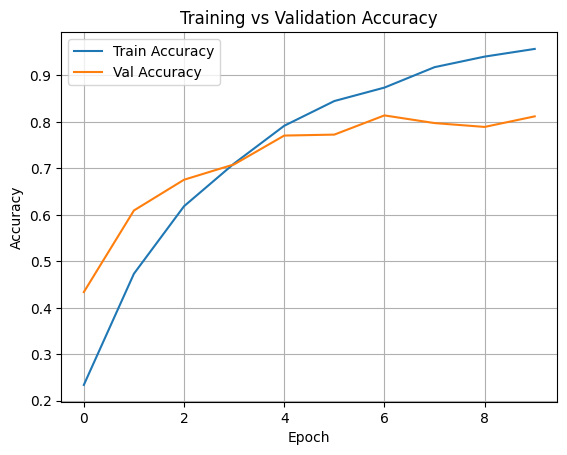

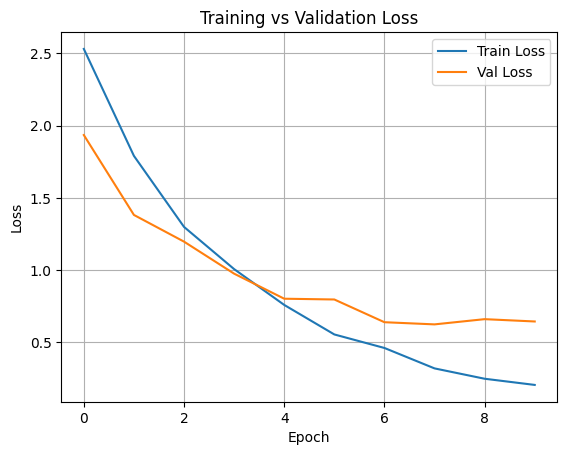

In [18]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()


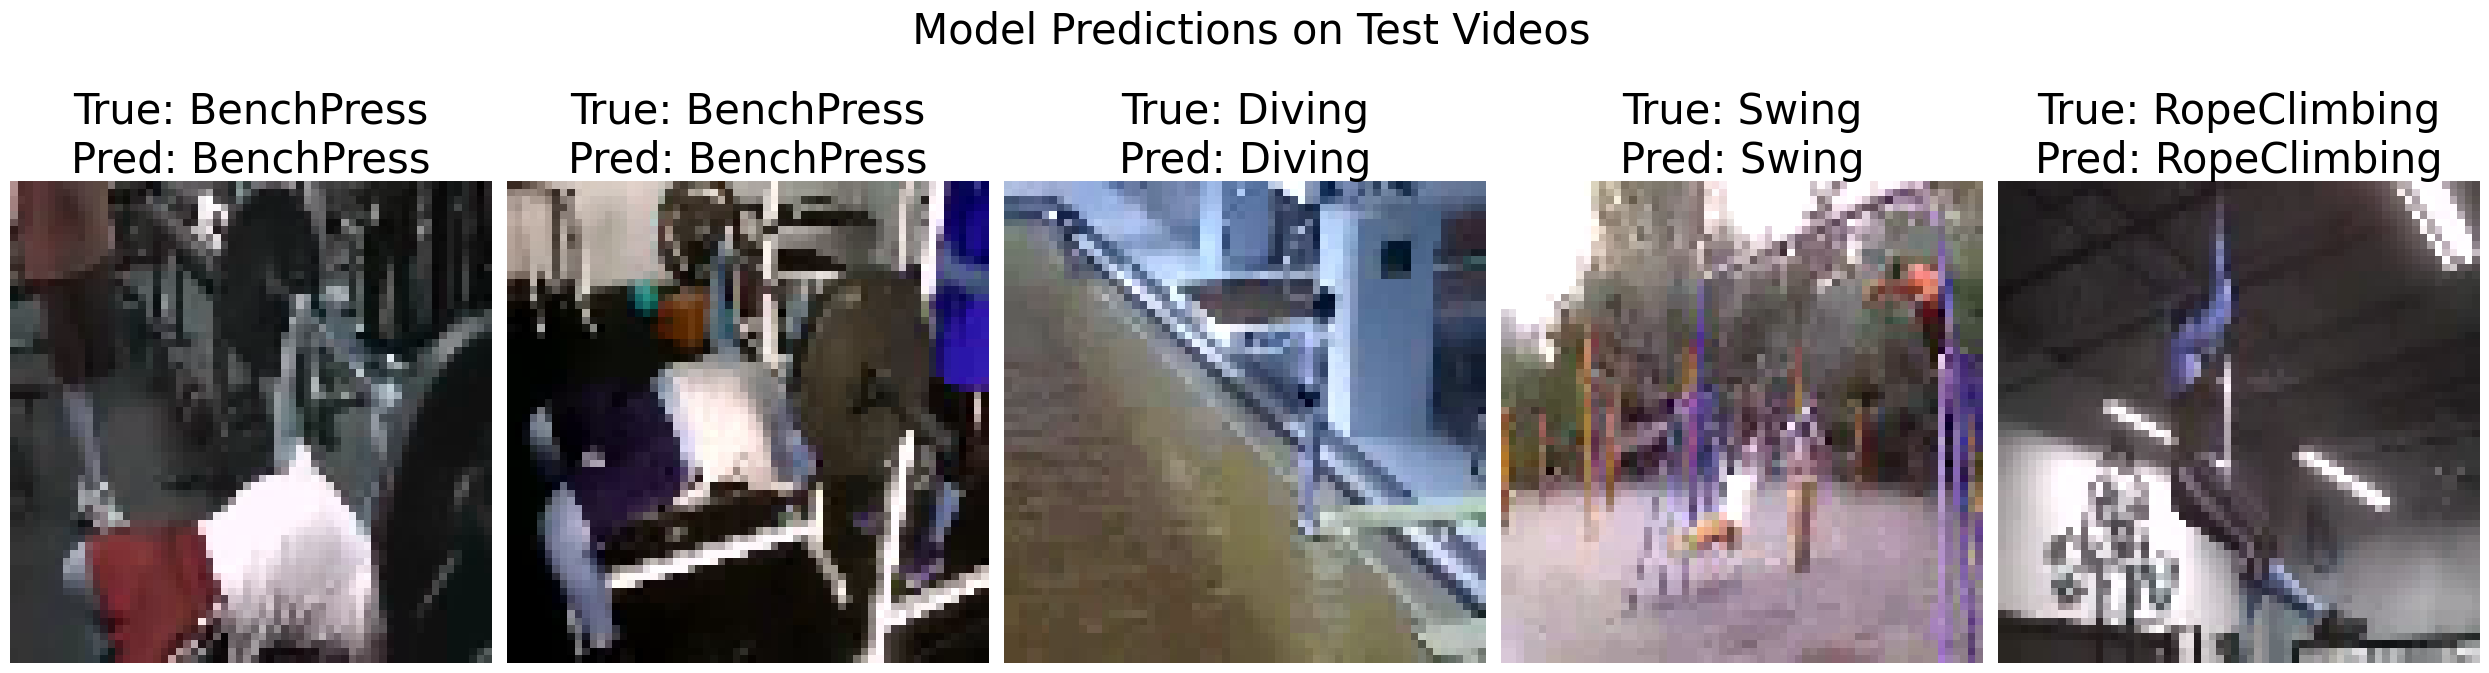

In [27]:
def show_predictions(model, X_test, y_test, class_names):

    indices = np.random.choice(len(X_test), 5, replace=False)
    fig, axes = plt.subplots(1, 5, figsize=(25, 8))  #  Wider and taller
    for i, idx in enumerate(indices):
        video = X_test[idx]
        true_label = class_names[np.argmax(y_test[idx])]
        prediction = model.predict(np.expand_dims(video, axis=0), verbose=0)
        predicted_label = class_names[np.argmax(prediction)]
        mid_frame = video[len(video) // 2]
        mid_frame = (mid_frame * 255).astype(np.uint8)
        frame = mid_frame  
        axes[i].imshow(frame)
        axes[i].set_title(f"True: {true_label}\nPred: {predicted_label}", fontsize=30)
        axes[i].axis('off')
    plt.suptitle(" Model Predictions on Test Videos", fontsize=30)
    plt.tight_layout()
    plt.show()
    
show_predictions(model, X_test, y_test, selected_classes)